#                                  timeseris Multi Label Clasification - RNN

# Load Data

In [188]:
import pandas as pd
import os
import numpy as np

In [189]:

file_name = "microsoft_stock_data"
root_folder = f'timeseris/multi-label-clasification/rnn/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,3/26/1986,0.057906,0.058437,0.055781,0.056312,22752000
1,3/27/1986,0.058969,0.058969,0.057906,0.057906,16848000
2,3/31/1986,0.058437,0.058969,0.057375,0.058969,12873600
3,4/1/1986,0.057906,0.058437,0.057906,0.058437,11088000
4,4/2/1986,0.058437,0.059500,0.057906,0.057906,27014400


#### Pilih tahun mulai data

In [190]:
# Pastikan kolom Date dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data mulai dari tahun 2000
df = df[df['Date'] >= '1995-01-01']

# (Opsional) urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,1995-01-03,2.302169,2.352372,2.299778,2.352372,39545600
1,1995-01-04,2.318903,2.323684,2.275872,2.304559,51611200
2,1995-01-05,2.280653,2.333246,2.271091,2.328465,39824000
3,1995-01-06,2.318903,2.342809,2.285434,2.290216,46681600
4,1995-01-09,2.304561,2.333248,2.285436,2.328467,46000000


#### tambahkan status green, red, dan netral || DayName

In [191]:
# === Tambahkan kolom nama hari ===
df['Day'] =  df['Date'].dt.day_name()  # bahasa Inggris

# Buat kondisi
conditions = [
    df['Close'] > df['Open'],
    df['Close'] < df['Open'],
    df['Close'] == df['Open']
]
choices = ['green', 'red', 'red']

df['Status'] = np.select(conditions, choices)
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status
0,1995-01-03,2.302169,2.352372,2.299778,2.352372,39545600,Tuesday,red
1,1995-01-04,2.318903,2.323684,2.275872,2.304559,51611200,Wednesday,green
2,1995-01-05,2.280653,2.333246,2.271091,2.328465,39824000,Thursday,red
3,1995-01-06,2.318903,2.342809,2.285434,2.290216,46681600,Friday,green
4,1995-01-09,2.304561,2.333248,2.285436,2.328467,46000000,Monday,red


#### Chart Donat

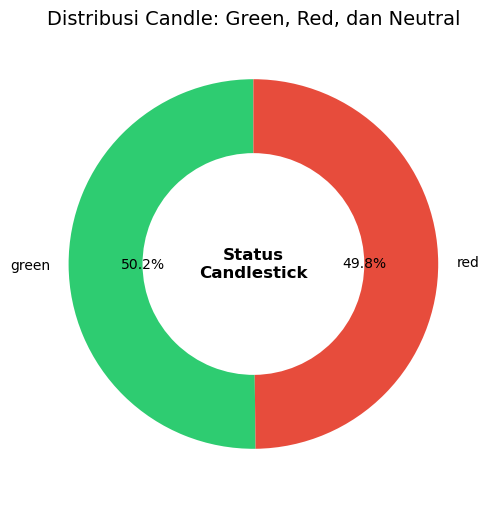

In [192]:
import matplotlib.pyplot as plt

# Contoh: df sudah punya kolom Status
# (kalau belum, bisa pakai kode sebelumnya untuk menambahkannya)

# Hitung jumlah masing-masing status
status_counts = df['Status'].value_counts()

# Warna donat
colors = {
    'green': '#2ecc71',   # hijau
    'red': '#e74c3c',     # merah
    'neutral': '#95a5a6'  # abu-abu
}

# Buat donut chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[k] for k in status_counts.index],
    wedgeprops=dict(width=0.4)  # buat efek donut
)

# Tambahkan teks di tengah
ax.text(0, 0, 'Status\nCandlestick', ha='center', va='center', fontsize=12, weight='bold')

plt.title('Distribusi Candle: Green, Red, dan Neutral', fontsize=14)
plt.show()

In [193]:
status_counts

Status
green    3890
red      3861
Name: count, dtype: int64

#### LabelEncoder

In [194]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_Day']            = le.fit_transform(df['Day'])
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day
0,1995-01-03,2.302169,2.352372,2.299778,2.352372,39545600,Tuesday,red,3
1,1995-01-04,2.318903,2.323684,2.275872,2.304559,51611200,Wednesday,green,4
2,1995-01-05,2.280653,2.333246,2.271091,2.328465,39824000,Thursday,red,2
3,1995-01-06,2.318903,2.342809,2.285434,2.290216,46681600,Friday,green,0
4,1995-01-09,2.304561,2.333248,2.285436,2.328467,46000000,Monday,red,1


#### Scaler

In [195]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_Day',
    'Close', 
    'High', 
    'Low',
    'Open',
    'Volume', 
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_Day' saved as scaler_label_Day.pkl
✅ Scaler for 'Close' saved as scaler_Close.pkl
✅ Scaler for 'High' saved as scaler_High.pkl
✅ Scaler for 'Low' saved as scaler_Low.pkl
✅ Scaler for 'Open' saved as scaler_Open.pkl
✅ Scaler for 'Volume' saved as scaler_Volume.pkl

All individual scalers saved successfully!


In [196]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day
0,1995-01-03,0.000085,0.000147,0.000136,0.000191,0.055458,Tuesday,red,0.75
1,1995-01-04,0.000117,0.000095,0.000090,0.000104,0.076122,Wednesday,green,1.00
2,1995-01-05,0.000045,0.000113,0.000081,0.000147,0.055935,Thursday,red,0.50
3,1995-01-06,0.000117,0.000130,0.000108,0.000078,0.067679,Friday,green,0.00
4,1995-01-09,0.000090,0.000113,0.000108,0.000147,0.066512,Monday,red,0.25


#### Mapping label

In [197]:
import json
mapping_dicts = {}

cols = [
    'Day',
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
print(mapping_table)

  feature original_value  label_value
0     Day        Tuesday         0.75
1     Day      Wednesday         1.00
2     Day       Thursday         0.50
3     Day         Friday         0.00
4     Day         Monday         0.25


#### Select Kolom To Trian

In [198]:
col_target = 'Status'
cols = [
    'Date',
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
    col_target
]
df = df[cols].copy()
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,Status
0,1995-01-03,0.75,0.000085,0.000147,0.000136,0.000191,0.055458,red
1,1995-01-04,1.00,0.000117,0.000095,0.000090,0.000104,0.076122,green
2,1995-01-05,0.50,0.000045,0.000113,0.000081,0.000147,0.055935,red
3,1995-01-06,0.00,0.000117,0.000130,0.000108,0.000078,0.067679,green
4,1995-01-09,0.25,0.000090,0.000113,0.000108,0.000147,0.066512,red


#### Tentukan target -> one-hot encoding

In [199]:
y_counts = df[col_target].value_counts(normalize=True)
labels = list(y_counts.index)

df_y_encoded = pd.get_dummies(df[col_target], prefix='y')

# Pastikan semua nama kolom lowercase dan spasi → underscore
df_y_encoded.columns = (
    df_y_encoded.columns.str.lower()
                        .str.replace(' ', '_')
)

# Gabungkan ke DataFrame utama
df = pd.concat([df.drop(col_target, axis=1), df_y_encoded.astype(int)], axis=1)
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,y_green,y_red
0,1995-01-03,0.75,0.000085,0.000147,0.000136,0.000191,0.055458,0,1
1,1995-01-04,1.00,0.000117,0.000095,0.000090,0.000104,0.076122,1,0
2,1995-01-05,0.50,0.000045,0.000113,0.000081,0.000147,0.055935,0,1
3,1995-01-06,0.00,0.000117,0.000130,0.000108,0.000078,0.067679,1,0
4,1995-01-09,0.25,0.000090,0.000113,0.000108,0.000147,0.066512,0,1


# Data Load To Train

#### select Future to traian

In [202]:
feature_cols = [
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    #'Volume',
]
target_cols = [col for col in df.columns if col.startswith('y_')]

#### Split data

In [203]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tgl_pembatas = '2020-01-01'
X_train = df[df['Date'] <= tgl_pembatas]
X_test  = df[df['Date'] > tgl_pembatas]
print(f'Train : f{X_train.shape}')
print(f'Test  : f{X_test.shape}')

Train : f(6294, 9)
Test  : f(1457, 9)


#### DataLoader

In [214]:
from data_set import MultiLabelTimeSeriesDataset
seq_length = 20
slide      = 1
# Buat dataset dengan class kamu
train_dataset = MultiLabelTimeSeriesDataset(X_train,seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols, normalize=False)
test_dataset  = MultiLabelTimeSeriesDataset(X_test, seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X shape: torch.Size([32, 20, 5])
y shape: torch.Size([32, 2])
tensor([[[0.5000, 0.0294, 0.0284, 0.0295, 0.0283],
         [0.0000, 0.0289, 0.0283, 0.0291, 0.0283],
         [0.2500, 0.0288, 0.0280, 0.0290, 0.0279],
         [0.7500, 0.0290, 0.0284, 0.0290, 0.0278],
         [1.0000, 0.0289, 0.0281, 0.0291, 0.0281],
         [0.5000, 0.0290, 0.0281, 0.0291, 0.0279],
         [0.0000, 0.0289, 0.0280, 0.0291, 0.0280],
         [0.2500, 0.0288, 0.0279, 0.0290, 0.0278],
         [0.7500, 0.0288, 0.0279, 0.0289, 0.0278],
         [1.0000, 0.0287, 0.0278, 0.0288, 0.0279],
         [0.5000, 0.0284, 0.0276, 0.0286, 0.0277],
         [0.0000, 0.0284, 0.0277, 0.0285, 0.0277],
         [0.2500, 0.0285, 0.0277, 0.0285, 0.0274],
         [0.7500, 0.0286, 0.0276, 0.0287, 0.0275],
         [1.0000, 0.0285, 0.0277, 0.0287, 0.0275],
         [0.5000, 0.0288, 0.0281, 0.0288, 0.0276],
         [0.0000, 0.0284, 0.0278, 0.0287, 0.0277],
         [0.2500, 0.0284, 0.0276, 0.0287, 0.0275],
         [0.7500, 0.

# Config

In [215]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_size"     : len(test_dataset[0][0][0]),
    "hidden_size"    : 32,
    "num_layers"     : 1,
    "num_classes"    : len(labels),
    "dropout"        : 0.1,
    "bidirectional"  : True,
    "early_stop_patience" : 30,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(bidirectional=True, col_target=Status, dropout=0.1, early_stop_patience=30, feature_cols=['label_Day', 'Close', 'High', 'Low', 'Open'], hidden_size=32, input_size=5, labels=['green', 'red'], num_classes=2, num_layers=1, threshold=0.5)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [223]:
from class_lib import RNN_MultiLabelClassifier
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False
model = RNN_MultiLabelClassifier(
    input_size=config.input_size, 
    hidden_size=config.hidden_size, 
    num_layers=config.num_layers, 
    num_classes=config.num_classes, 
    dropout=config.dropout, 
    bidirectional=config.bidirectional
).to(device)

#Criterion
criterion =nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

/home/arindyproject/miniconda3/envs/ai2/lib/python3.8/site-packages/torch/nn/modules/rnn.py:47: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1048.66it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6943 │ 0.6936 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.5000 │ 0.5000 │ │ green │  0.5310  │
│ Subset Accuracy  │ 0.0000 │ 0.0000 │ │  red  │  0.4690  │
│ Micro F1         │ 0.6667 │ 0.6667 │ └───────┴──────────┘
│ Macro F1         │ 0.6667 │ 0.6661 │                     
│ Overall Accuracy │ 0.5000 │ 0.5000 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6943 | Test_cost  = 0.6936 | Train_score = 0.5000 | Test_score = 0.5000 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6930 | Test_cost  = 0.6936 | Train_score = 0.5052 | Test_score = 0.4854 |
==> EarlyStop patience = 18 | Best test_score: 0.5000


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1021.18it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6930 │ 0.6936 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4947 │ 0.5132 │ │ green │  0.5045  │
│ Subset Accuracy  │ 0.5053 │ 0.2269 │ │  red  │  0.4690  │
│ Micro F1         │ 0.5053 │ 0.5927 │ └───────┴──────────┘
│ Macro F1         │ 0.3357 │ 0.5835 │                     
│ Overall Accuracy │ 0.5053 │ 0.4868 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6930 | Test_cost  = 0.6936 | Train_score = 0.5053 | Test_score = 0.4868 |


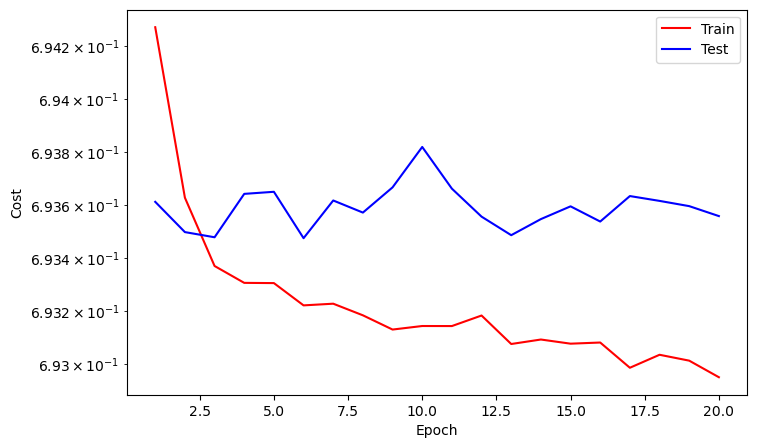

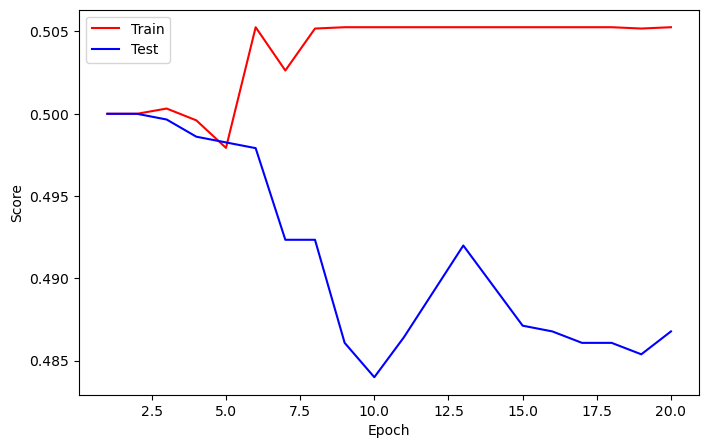

==> EarlyStop patience = 19 | Best test_score: 0.5000


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1230.21it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6930 │ 0.6935 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4947 │ 0.5104 │ │ green │  0.5101  │
│ Subset Accuracy  │ 0.5053 │ 0.2039 │ │  red  │  0.4690  │
│ Micro F1         │ 0.5053 │ 0.6030 │ └───────┴──────────┘
│ Macro F1         │ 0.3357 │ 0.5971 │                     
│ Overall Accuracy │ 0.5053 │ 0.4896 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6930 | Test_cost  = 0.6935 | Train_score = 0.5053 | Test_score = 0.4896 |
==> EarlyStop patience = 20 | Best test_score: 0.5000


...


Epoch    30
Train_cost  = 0.6929 | Test_cost  = 0.6935 | Train_score = 0.5055 | Test_score = 0.4910 |
==> EarlyStop patience = 29 | Best test_score: 0.5000


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 967.11it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6929 │ 0.6934 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4933 │ 0.5066 │ │ green │  0.5177  │
│ Subset Accuracy  │ 0.4603 │ 0.1343 │ │  red  │  0.4690  │
│ Micro F1         │ 0.5286 │ 0.6272 │ └───────┴──────────┘
│ Macro F1         │ 0.4269 │ 0.6263 │                     
│ Overall Accuracy │ 0.5067 │ 0.4934 │                     
└──────────────────┴────────┴────────┘


Epoch    31
Train_cost  = 0.6929 | Test_cost  = 0.6934 | Train_score = 0.5067 | Test_score = 0.4934 |
==> EarlyStop patience = 30 | Best test_score: 0.5000
==> Execute Early Stopping at epoch: 31 | Best test_score: 0.5000
==> Best model is saved at timeseris/multi-label-clasification/rnn/microsoft_stock_data/


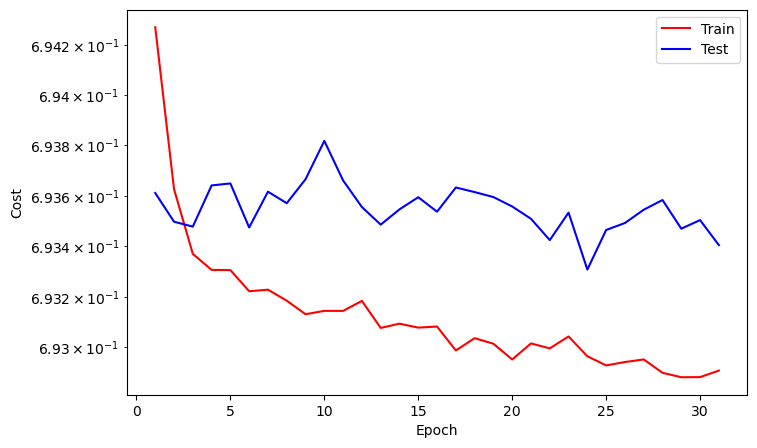

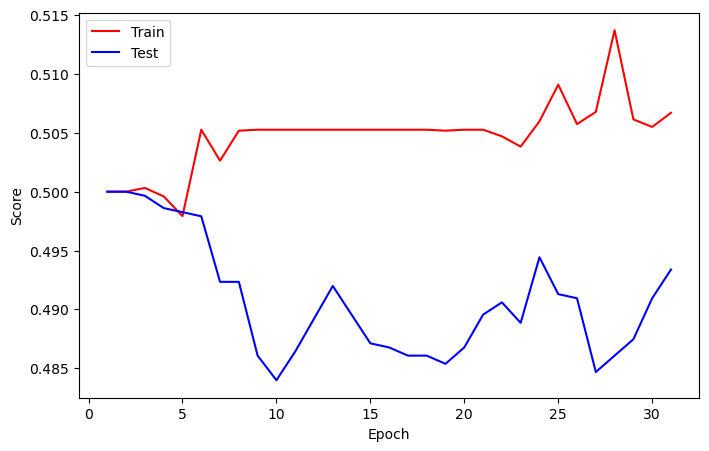

⏹️ Training dihentikan oleh early stopping.

In [224]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

# Evaluate

In [225]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, target_cols,criterion, device, config.threshold)

       📊 Evaluasi Model         🎯 Per-Label Accuracy
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━┳━━━━━━━━━┓
┃ Metrik              ┃  Nilai ┃ ┃  Label  ┃ Akurasi ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━╇━━━━━━━━━┩
│ 🔹 Overall Accuracy │ 0.5000 │ │ y_green │ 0.5310  │
│ ✅ Subset  Accuracy │ 0.0000 │ │  y_red  │ 0.4690  │
│ 💥 Loss (avg)       │ 0.6936 │ └─────────┴─────────┘
│ 📉 Hamming Loss     │ 0.5000 │                      
│ ⚖️  Micro F1-score   │ 0.6667 │                      
│ 📈 Macro F1-score   │ 0.6661 │                      
└─────────────────────┴────────┘

In [226]:
hsl = hsl['df']
b = hsl[hsl['Benar (%)'] == 100]
b.head(300)

,Target,Prediksi,Benar (%)


In [227]:
b.shape

(0, 3)

In [228]:
s = hsl[hsl['Benar (%)'] == 0]
s.head(300)

,Target,Prediksi,Benar (%)


In [229]:
s.shape

(0, 3)